# Lab Report #4: Portfolio Construction
RSM338\
Prof. K. Mott\
Submitted by Dong-Hyun Michael Kim\
2026-03-10

## 1. Data Preparation
We will be using daily closing price data of all S&P 500 stocks over the last 10 years listed in the data (March 4th 2015 to 2025). This conveniently ignores the April 2025 stock market crash due to the introduction of new tariff policies by the American government.

We will only include stocks that have data recorded for each day in this time period. This allows us to compare statistics between stocks on the same basis without any more assumptions. There is also a another option where we only include dates that have data filled in for every single stock in the index, but on top of this being virtually impossible (more than 500 stocks are listed in the data for a 500 stock index), this would also give us more features at a cost of less observations, which is quite unideal for our purposes.

In addition, we will use daily closing value data for the entire market index. Finally, we will also convert the daily 10-year US Treasury constant maturity rate (sourced from FRED) into a daily continuously compounded rate, which we will consider the risk free rate. The formula to convert is as follows:
$r^{daily}_f=ln(1+y/100)/252$, where $y$ is the 10-year constant maturity rate.

After we collect all these values into one pandas dataframe, we remove any dates for which at least one of the values are missing, for similar reasons as above.

In [76]:
import pandas as pd
import numpy as np

# File paths
prices = 'prices.csv'
market = 'market.csv'
DGS_ten = 'DGS10.csv'

# import csvs into dataframes
prices_df = pd.read_csv(
    prices,
    skiprows=range(1, 11395),
    sep=',',
    nrows=2516,
    index_col=0,
    parse_dates=True
)

market_df = pd.read_csv(
    market,
    skiprows=range(1, 11395),
    sep=',',
    nrows=2516,
    index_col=0,
    parse_dates=True
)

rf_df = pd.read_csv(
    DGS_ten,
    skiprows=range(1, 13869),
    sep=',',
    nrows=2611,
    index_col=0,
    parse_dates=True
)

# Create index dataframe containing all possible dates
days_df = pd.DataFrame(index=pd.date_range('2015-03-03', '2025-03-04', freq='D'))

# remove stocks with missing values
prices_df = prices_df.dropna(axis=1)

# Combine dataframes
df = pd.concat([days_df, prices_df, market_df, rf_df], axis=1, sort=True)

# convert treasury's 10 year constant maturity rate to a daily rate
df['DGS10'] = np.log(1 + df['DGS10'] / 100) / 252

# rename last two columns
df = df.rename(columns={'^GSPC': 'Market', 'DGS10': 'Rf'})

# drop all rows where at least one column is missing a value
df = df.dropna(axis=0)

We then compute daily log returns for each stock as well as the market index, using the formula $r_t = ln(\frac{P_t}{P_{t-1}})$. We choose to use log returns as they are computationally convenient (compounding works additively instead of multiplicatively, among other properties).

In [77]:
# compute ratio of current value to previous value for all columns (except risk free column)
lr_df = df.iloc[:, :-1].pct_change() + 1
# first row can no longer be used since its values rely on the data of the previous row
lr_df = lr_df.drop(df.index[0])
lr_df = np.log(lr_df)

Next we calculate annualized expected excess returns. Given $T$ trading days, we get $\hat{u}_i=252\cdot\bar{r}_i-r_f$, where $\bar{r}_i=\frac{1}{T}\sum_{t=1}^T r_{i,t}$. We also compute the annualized covariance matrix $\hat{\Sigma}=252\cdot\hat{\Sigma}_{daily}$, where $\hat{\Sigma}_{daily}$ is the sample covariance matrix of daily log returns.

In [78]:
an_returns = (lr_df.mean() - df['Rf'].mean()) * 252
an_cov_matrix = lr_df.cov() * 252

Some notable outliers:

In [79]:
print(f"Top 3 stocks by return:\n{an_returns.nlargest(3).to_string()}\n")
print(f"Bottom 3 stocks by return:\n{an_returns.nsmallest(3).to_string()}\n")

variances = pd.Series(np.diag(an_cov_matrix), index=an_cov_matrix.columns)
print(f"Top 3 stocks by volatility:\n{variances.nlargest(3).to_string()}\n")
print(f"Bottom 3 stocks by volatility:\n{variances.nsmallest(3).to_string()}\n")

Top 3 stocks by return:
NVDA    0.523722
TPL     0.331609
AMD     0.322078

Bottom 3 stocks by return:
VTRS   -0.194793
WBA    -0.194269
PARA   -0.175168

Top 3 stocks by volatility:
ENPH    0.648376
SMCI    0.448170
NCLH    0.369353

Bottom 3 stocks by volatility:
Market    0.032162
KO        0.032430
JNJ       0.032903



Among the top 3 returners we see familiar faces like Nvidia and AMD, who have in recent years enjoyed substantial growth due to demand from generative AI among other reasons. Among the worst performers in this time period is the Walgreens Boot Alliance, whose stock price notably fell by more than 55% in the first half of 2024 after they announced the closure of more than 2000 locations.

The top 3 stocks by volatility are not as easily expected, although an explanation for this may be that people often recall recent volatile stocks a lot easier than those over long periods of time. The least volatile stock being the index is perfectly expected, although we personally did not expect the other two either.
## 2. Plotting the Security Market Line
Now that we've computed log returns from price data, we can now run regressions on them under the CAPM model. The equation is as follows: $r_{i,t}-r_{f,t}=\alpha_i+\beta_i(r_{m,t}-r_{f,t})+\epsilon_{i,t}$, where
- $r_{i,t}-r_{f,t}$ is excess stock returns,
- $r_{m,t}-r_{f,t}$ is excess market returns, and
- $\epsilon_{i,t}$ represents noise.

In [ ]:
from sklearn.linear_model import LinearRegression

monthly_df = pd.concat([lr_df, df['Rf']], axis=1, sort=True).resample('ME').sum()


rf_returns = monthly_df['Rf']
market_excess = monthly_df['Market'] - rf_returns
results = {}

for stock in monthly_df.iloc[:, :-2]:
    stock_excess = monthly_df[stock] - rf_returns
    
    X = market_excess.values.reshape(-1, 1)
    y = stock_excess.values
    
    model = LinearRegression()
    model.fit(X, y)

    # Calculate standard error of beta
    y_pred = model.predict(X)
    residuals = y - y_pred
    mse = np.sum(residuals**2) / (len(y) - 2)  # Degrees of freedom: n - 2
    x_variance = np.sum((X.flatten() - X.mean())**2)
    beta_se = np.sqrt(mse / x_variance)
    
    results[stock] = {
        'alpha': model.intercept_,
        'beta': model.coef_[0],
        'r_squared': model.score(X, y),
        'std_error': beta_se
    }

capm_results = pd.DataFrame(results).T
capm_results

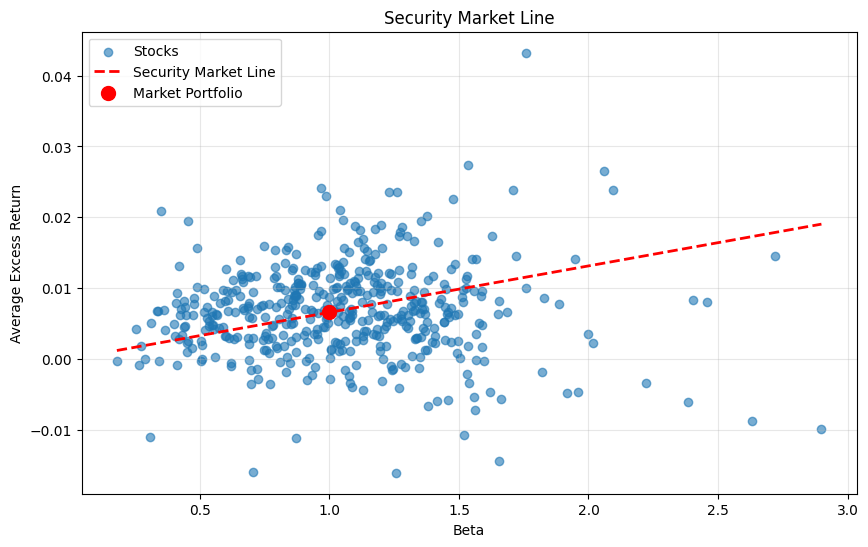

In [86]:
import matplotlib.pyplot as plt

# Calculate average excess returns for each stock
avg_excess_returns = {}
for stock in monthly_df.columns[:-2]:  # Exclude Market and Rf
    avg_excess_returns[stock] = (monthly_df[stock] - monthly_df['Rf']).mean()

avg_excess_returns = pd.Series(avg_excess_returns)

# Get market excess return (slope of SML)
market_excess_return = (monthly_df['Market'] - monthly_df['Rf']).mean()

# Scatter plot: beta vs excess return
plt.figure(figsize=(10, 6))
plt.scatter(capm_results['beta'], avg_excess_returns, alpha=0.6, label='Stocks')

# SML line: Excess Return = Beta * Market Excess Return
beta_range = np.linspace(capm_results['beta'].min(), capm_results['beta'].max(), 100)
sml_line = beta_range * market_excess_return
plt.plot(beta_range, sml_line, 'r--', label='Security Market Line', linewidth=2)

# Market portfolio point (beta=1, return=market excess return)
plt.scatter([1], [market_excess_return], color='red', s=100, label='Market Portfolio', zorder=5)

plt.xlabel('Beta')
plt.ylabel('Average Excess Return')
plt.title('Security Market Line')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Again, some notable outliers:

In [94]:
alpha_df = capm_results[['alpha']].sort_values('alpha', ascending=False)
print(f"Top 5 stocks by alpha:\n{alpha_df.head().to_string()}\n")
print(f"Bottom 5 stocks by alpha:\n{alpha_df.tail().to_string()}\n")

Top 5 stocks by alpha:
         alpha
NVDA  0.031702
LLY   0.018539
AXON  0.017852
TPL   0.017294
AVGO  0.016555

Bottom 5 stocks by alpha:
         alpha
CCL  -0.021736
VTRS -0.024325
PARA -0.025335
NCLH -0.026040
APA  -0.028879



## Plotting the Efficient Frontier
For a target return $\mu_{target}$, there is a closed-form solution to finding the weights on each stock that give us the portfolio with the least variance. We first define the following scalars:
$$A=\vec{1}^\top\Sigma^{-1}\mu$$
$$B=\mu^\top\Sigma^{-1}\mu$$
$$C=\vec{1}^\top\Sigma^{-1}\vec{1}$$
$$D=BC-A^2$$
We then define the following multipliers:
$$\lambda_1=\frac{C\cdot\mu_{target}-A}{D},\lambda_2=\frac{B-A\cdot\mu_{target}}{D}$$
Which gives us our optimal weights:
$$\vec{w}^*=\Sigma^{-1}(\lambda_1\mu+\lambda_2\vec{1})$$

In [105]:
ones = np.ones(len(an_cov_matrix))
inv_cov_matrix = np.linalg.inv(an_cov_matrix)
a = ones.T @ inv_cov_matrix @ an_returns
b = an_returns.T @ inv_cov_matrix @ an_returns
c = ones.T @ inv_cov_matrix @ ones
d = b * c - a**2

def lambda_one(target_return):
    return (c*target_return - a) / d

def lambda_two(target_return):
    return (b - a*target_return) / d


Now we can use the annualized expected excess returns as well as the annualized covariance matrix to plot the efficient frontier. 

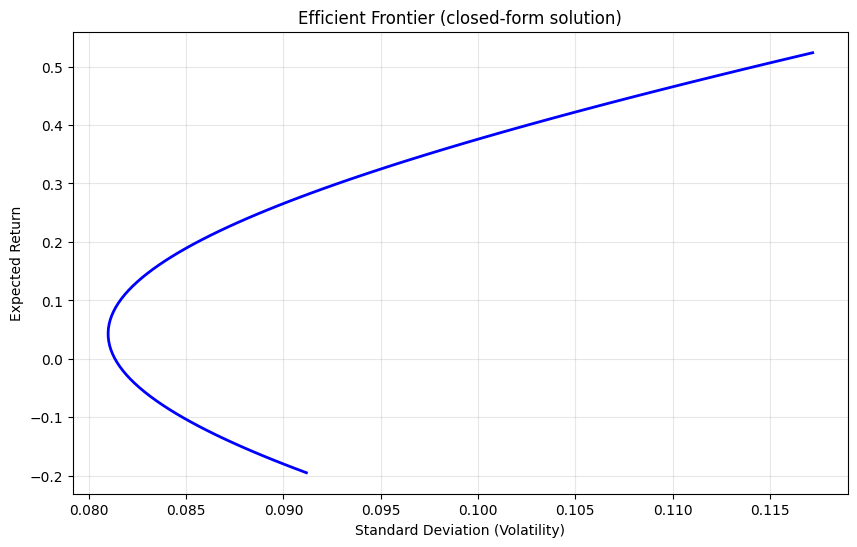

In [117]:
# Generate a range of target returns
target_returns = np.linspace(an_returns.min(), an_returns.max(), 100)

portfolio_returns = []
portfolio_stds = []

for target_ret in target_returns:
    lambda1 = lambda_one(target_ret)
    lambda2 = lambda_two(target_ret)
    
    # calculate weights using closed form solution
    weights = inv_cov_matrix @ (lambda1 * an_returns + lambda2 * ones)
    
    # Portfolio return and standard deviation
    port_return = weights @ an_returns
    port_std = np.sqrt(weights @ an_cov_matrix @ weights)
    
    portfolio_returns.append(port_return)
    portfolio_stds.append(port_std)

# Plot the efficient frontier
plt.figure(figsize=(10, 6))
plt.plot(portfolio_stds, portfolio_returns, 'b-', linewidth=2, label='Efficient Frontier')
# plt.scatter(np.sqrt(np.diag(an_cov_matrix)), an_returns, alpha=0.3, s=20, label='Individual Stocks')
plt.xlabel('Standard Deviation (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (closed-form solution)')
plt.grid(True, alpha=0.3)
plt.show()

We can also identify the associated Global Minimum Variance (GMV) portfolio as well as the tangency portfolio.

In [ ]:
from math import e

# Global Minimum Variance Portfolio (GMVP)
gmvp_weights = inv_cov_matrix @ ones / c

gmvp_return = gmvp_weights @ an_returns
gmvp_std = np.sqrt(gmvp_weights @ an_cov_matrix @ gmvp_weights)

print(f"GMVP Return: {((e**gmvp_return-1)*100):.6f}%")
print(f"GMVP Std Dev: {gmvp_std:.6f}")
print(f"GMVP Weights: {gmvp_weights}")

# Tangency Portfolio (maximum Sharpe ratio)
rf_annual = df['Rf'].mean() * 252  # Annualized risk-free rate

# Excess returns
excess_returns = an_returns - rf_annual

# Tangency portfolio weights
tangency_weights = inv_cov_matrix @ excess_returns
tangency_weights = tangency_weights / np.sum(tangency_weights)  # normalize

tangency_return = tangency_weights @ an_returns
tangency_std = np.sqrt(tangency_weights @ an_cov_matrix @ tangency_weights)
tangency_sharpe = (tangency_return - rf_annual) / tangency_std

print(f"\nTangency Return: {tangency_return:.6f}")
print(f"Tangency Std Dev: {tangency_std:.6f}")
print(f"Tangency Portfolio: {tangency_weights}")

GMVP Return: 4.386524%
GMVP Std Dev: 0.080987
GMVP Weights: [-2.92125386e-02 -1.44701260e-02  2.62938850e-02 -2.66664186e-02
 -3.40972718e-03 -2.46528755e-02 -4.11841293e-03  1.76173934e-02
 -2.37756587e-02 -3.55878386e-02 -1.56457810e-02 -6.25619579e-03
  2.88655914e-02 -1.91861507e-02  2.36005142e-02  1.61988203e-03
  3.25665703e-02  1.20874086e-02  6.06712039e-03 -4.30589314e-03
 -6.73988172e-03 -1.37110622e-02  8.76995072e-03 -1.78463460e-02
  6.68142441e-02 -6.82642107e-03 -1.62187330e-02 -3.50206165e-02
 -9.71706749e-02  6.59012543e-03 -1.51668508e-02 -6.69416029e-03
 -5.40889408e-03  6.04096490e-03  3.93178244e-03 -4.93559444e-03
 -1.66863957e-02  2.37638880e-02 -5.02658453e-03 -2.98503028e-02
 -2.72313416e-03  2.35875381e-02 -5.57042784e-03 -4.07980910e-04
  2.87863624e-03 -3.30948587e-02  9.07180422e-03  1.14864565e-02
  4.02984304e-02 -1.77107363e-02  1.28035337e-02  4.94928380e-03
  5.90526251e-04  9.04017157e-06  2.75025601e-02 -3.43187309e-03
 -2.61896176e-02  5.72991211e-

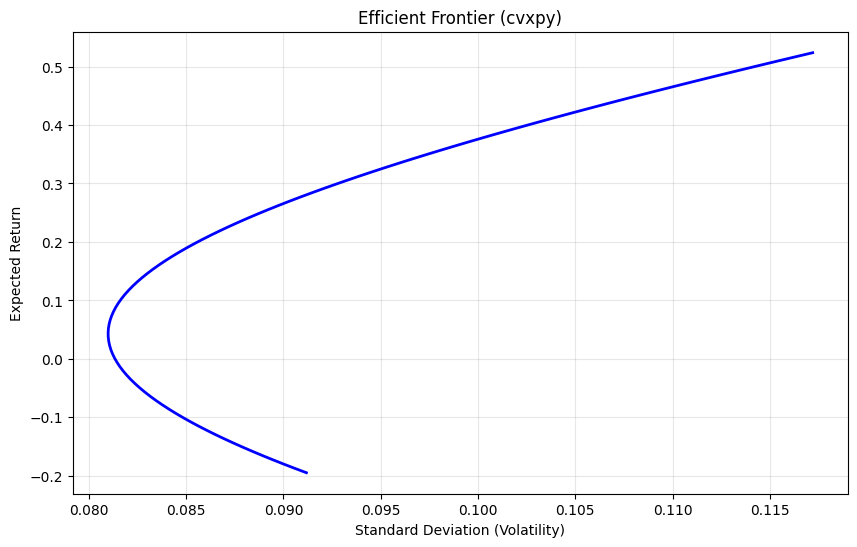

In [118]:
import cvxpy as cp

# Generate a range of target returns
target_returns = np.linspace(an_returns.min(), an_returns.max(), 100)

portfolio_returns = []
portfolio_stds = []

for target_ret in target_returns:
    # Decision variable: portfolio weights
    w = cp.Variable(len(an_returns))
    
    # Objective: minimize portfolio variance
    portfolio_variance = cp.quad_form(w, an_cov_matrix)
    
    # Constraints
    constraints = [
        cp.sum(w) == 1,              # weights sum to 1
        w @ an_returns == target_ret  # target return constraint
    ]
    
    # Solve optimization problem
    prob = cp.Problem(cp.Minimize(portfolio_variance), constraints)
    prob.solve()
    
    # Extract results
    port_return = w.value @ an_returns
    port_std = np.sqrt(w.value @ an_cov_matrix @ w.value)
    
    portfolio_returns.append(port_return)
    portfolio_stds.append(port_std)

# Plot the efficient frontier
plt.figure(figsize=(10, 6))
plt.plot(portfolio_stds, portfolio_returns, 'b-', linewidth=2, label='Efficient Frontier')
# plt.scatter(np.sqrt(np.diag(an_cov_matrix)), an_returns, alpha=0.3, s=20, label='Individual Stocks')
plt.xlabel('Standard Deviation (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (cvxpy)')
plt.grid(True, alpha=0.3)
plt.show()